# Marching Qubes Vertex Classification with EHands and QCrank
## Brandon Watanabe


In [815]:
# imports, part 1
import numpy as np
import matplotlib.pyplot as plt
import math
from math import asin, sqrt, pi
import random
import sys
from dotenv import load_dotenv
import os
from pathlib import Path
from collections import defaultdict

import qiskit
from qiskit import QuantumCircuit
from qiskit import transpile
from qiskit.quantum_info import Statevector, Operator, Pauli
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_distribution, array_to_latex
from qiskit.circuit.library import HGate, XGate, YGate, ZGate, CXGate
print(f"Qiskit version: {qiskit.__version__}")

Qiskit version: 2.3.0


In [816]:
# Adapted from Chris Pestano's QSobel
load_dotenv()
data_encoder_circuits_path = os.getenv('DATA_ENCODER_CIRCUITS_PATH')

if data_encoder_circuits_path is None:
    raise EnvironmentError("DATA_ENCODER_CIRCUITS_PATH environment variable is not set. Please set it to the path of data-encoder-circuits.")

print(f"Using DATA_ENCODER_CIRCUITS_PATH from environment variable: {data_encoder_circuits_path}")
circuits_path = data_encoder_circuits_path

# Add to sys.path if not already present
if circuits_path not in sys.path:
    sys.path.insert(0, circuits_path)

print(f"Added to sys.path: {circuits_path}")
print(f"Current working directory: {os.getcwd()}")

from datacircuits import qcrank, frqi
from datacircuits import ParametricQCrankV2
from datacircuits.ParametricQCrankV2 import ParametricQCrankV2 as qcrank_reco_from_yields

Using DATA_ENCODER_CIRCUITS_PATH from environment variable: C:\Users\waffles\Documents\school_work\QC-Classes\References\repos\data-encoder-circuits
Added to sys.path: C:\Users\waffles\Documents\school_work\QC-Classes\References\repos\data-encoder-circuits
Current working directory: c:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis


In [817]:
from qiskit_aer import AerSimulator

sim = AerSimulator()

print(sim)
print(f"\nConfiguration: {sim.configuration()}")

if hasattr(sim, 'available_methods'):
    print(f"Available methods: {sim.available_methods()}")
else:
    print(sim.configuration())

if hasattr(sim, 'available_devices'):
    print(f"Available devices: {sim.available_devices()}")
else:
    print(sim.configuration())   

AerSimulator('aer_simulator')

Configuration: <qiskit_aer.backends.backendconfiguration.AerBackendConfiguration object at 0x000001B2C7DA51D0>
Available methods: ('automatic', 'statevector', 'density_matrix', 'stabilizer', 'matrix_product_state', 'extended_stabilizer', 'unitary', 'superop')
Available devices: ('CPU',)


In [818]:
# helper function needed to use plot_bloch_vector() method: converts statevector to 3 values
def statevector_to_bloch_vector(state):
    bloch_x = 2 * np.real(state[0] * np.conj(state[1]))
    bloch_y = 2 * np.imag(state[1] * np.conj(state[0]))
    bloch_z = np.abs(state[0])**2 - np.abs(state[1])**2
    return [bloch_x, bloch_y, bloch_z]

# helper function to plot two bloch spheres side by side
# inputs are two statevectors and two title strings
def plot_2bloch_spheres(state1, title1, state2, title2):
    fig, axs = plt.subplots(1, 2, figsize=(10, 4), subplot_kw={'projection': '3d'})
    
    plot_bloch_vector(statevector_to_bloch_vector(state1), ax=axs[0])
    axs[0].set_title(title1, pad=20)

    plot_bloch_vector(statevector_to_bloch_vector(state2), ax=axs[1])
    axs[1].set_title(title2, pad=20)

    plt.show()

In [819]:
def run_sim_job(qc, n_shots = 2**8, verbose=False):
    transpiled_circuit = transpile(qc, sim)    
    job = sim.run(transpiled_circuit, shots=n_shots)
    result = job.result()
    
    # Get counts and output distribution
    counts = result.get_counts(transpiled_circuit)

    if verbose:
        print("Circuit before transpilation")
        display(qc.draw('mpl'))
        print("Circuit after transpilation")
        display(transpiled_circuit.draw('mpl', style="iqp"))

        print("Counts:")
        print(counts)
        display(plot_distribution(counts))

    return counts

In [820]:
def display_statevector(qc):
    # Get Statevector
    state = Statevector.from_instruction(qc)

    # Display Statevector
    print("\nStatevector:")
    display(state.draw("latex"))

    matrix_form = np.array(state).reshape(-1, 1)
    print("\nStatevector as a matrix:")
    display(array_to_latex(matrix_form))
    
    # Display the Unitary Matrix
    print("Unitary matrix:")
    display(Operator(qc).draw("latex"))

    # Display Bloch Sphere
    display(plot_bloch_multivector(state))

    return state

In [821]:
def compute_qubit_counts(data):
    # TODO: Handle non-power-of-two datasets
    data = np.array(data)
    n_data = data.shape[0]

    # number of data qubits
    if data.ndim == 1:
        data_qubits = 1
    else:
        data_qubits = data.shape[1]

    # number of address qubits
    address_qubits = math.ceil(math.log2(n_data))

    return address_qubits, data_qubits

In [822]:
def encode_with_qcrank(data):
    nq_addr, nq_data = compute_qubit_counts(data)

    print("Number of address qubits needed:", nq_addr)
    print("Number of data qubits needed:", nq_data)

    # reshape data to have shape (n_data, nq_data, 1) for compatibility with the data encoding circuit
    data = data.reshape(n_data, nq_data, 1)
    print("Input data values:")
    print(data) 

    # Adapted from Chris Pestano's QSobel
    # This function is from an outside directory provided by the AQuA-DATA team at LBNL (see data-encoder-circuits directory)
    param_qcrankObj = ParametricQCrankV2.ParametricQCrankV2( nq_addr, nq_data, useCZ=False, measure=False, barrier=True )
    # Important NOTE: QCrankV2 has address qubits on the LSQBs, V1 had an option to reverse bits during initialization, but that is not present in V2

    param_qcrankObj.bind_data(data)
    # generate the instantiated circuits
    # rotation gates values are mapped to their respective gates 
    data_circs = param_qcrankObj.instantiate_circuits()
    print(f"Generated {len(data_circs)} data encoding circuits.")
    addr_qubits = list(range(nq_addr))

    return {
    'data_circs': data_circs,
    'param_qcrankObj': param_qcrankObj,
    'nq_addr': nq_addr,
    'nq_data': nq_data,
    'addr_qubits': addr_qubits
    }

In [823]:
def ehands_addition(qc, q_a, q_b, weight, negation=False):
    alpha = np.arccos(1 - 2 * weight)

    qc_add = QuantumCircuit(2)

    if negation:
        qc_add.x(1)

    qc_add.rz(pi/2, 1)
    qc_add.cx(0, 1)
    qc_add.ry(alpha/2, 0)
    qc_add.cx(1, 0) 
    qc_add.ry(-alpha/2, 0)

    return qc.compose(qc_add, qubits=[q_a, q_b])


In [824]:
def get_EV(counts, nq_addr, target_qubit='1'):
    """
    Adapted from Chris Pestano's QSobel get_EV().
    
    counts: dict of counts from Qiskit simulator (basis state -> count)
    nq_addr: number of address qubits
    target_qubit: the data qubit to measure (as a string, e.g., '1')
    
    Returns:
        np.array of expectation values <Z> for each element
    """
    n_elements = 2**nq_addr
    expectations = np.zeros(n_elements, dtype=float)
    
    for i in range(n_elements):
        # Binary string for this address
        addr_bits_str = bin(i)[2:].zfill(nq_addr)
        
        # Filter counts for this address
        c_0 = c_1 = 0
        for k, v in counts.items():
            # First nq_addr bits are address, remaining are data qubits
            if k[:nq_addr] == addr_bits_str:
                # target_qubit index from the right
                idx = -int(target_qubit)
                if k[idx] == '0':
                    c_0 += v
                else:
                    c_1 += v
        
        # Compute expectation <Z> = (c0 - c1) / (c0 + c1)
        if c_0 + c_1 == 0:
            expectations[i] = 0  # no measurement for this element
        else:
            expectations[i] = 1 - (2*c_1/(c_0 + c_1))
    
    return expectations

## Test of addition and subtraction using EHands EVEN encoding and decoding on 2 qubits 

In [838]:
def find_optimal_W(qc, x0, x1, steps=20, negation=False, simulate=True):
    weight_range = np.linspace(0, 1, steps + 1)
    best_weight = None
    best_expectation = None
    ev_list = []

    real_value = x0 - x1 if negation else x0 + x1

    for w in weight_range:
        ev = 0
        if simulate:
            qc_test = qc.copy()
            qc_test = ehands_addition(qc_test, q_a=0, q_b=1, weight=w, negation=negation)
            qc_test.measure(0, 0)
            
            counts = run_sim_job(qc_test, n_shots=n_shots, verbose=False)
            ev = (counts.get('0', 0) - counts.get('1', 0)) / n_shots

        else:
            if do_negation:
                ev = w*x0 - (1-w)*x1
            else:
                ev = w*x0 + (1-w)*x1

        ev_list.append(ev)
        
        # Update best weight
        if best_weight is None or abs(ev - real_value) < abs(best_expectation - real_value):
            best_weight = w
            best_expectation = ev

    # Plot expectation values vs weights
    plt.figure(figsize=(8, 5))
    plt.plot(weight_range, ev_list, 'o-', label='Expectation Value')
    plt.axhline(real_value, color='r', linestyle='--', label=f'Real Value ({real_value:.4f})')
    plt.xlabel("Weight")
    plt.ylabel("Expectation Value")
    plt.title("Expectation Value vs Weight")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Optimal weight found: {best_weight:.2f} with expectation {best_expectation:.4f}")
    return best_weight

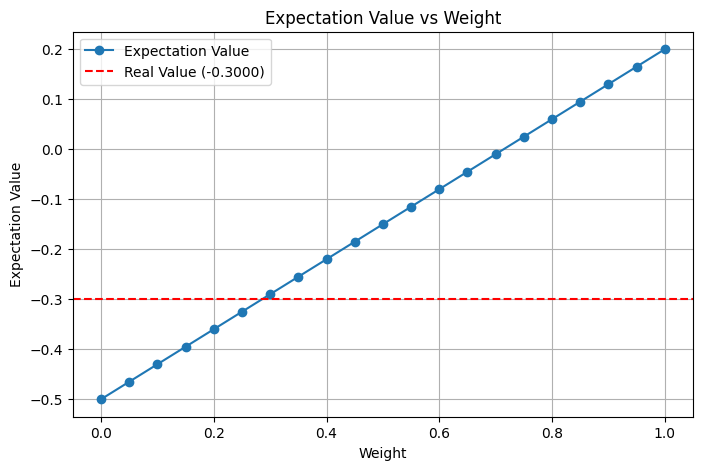

Optimal weight found: 0.30 with expectation -0.2900

Statevector:


<IPython.core.display.Latex object>


Statevector as a matrix:


<IPython.core.display.Latex object>

Unitary matrix:


<IPython.core.display.Latex object>

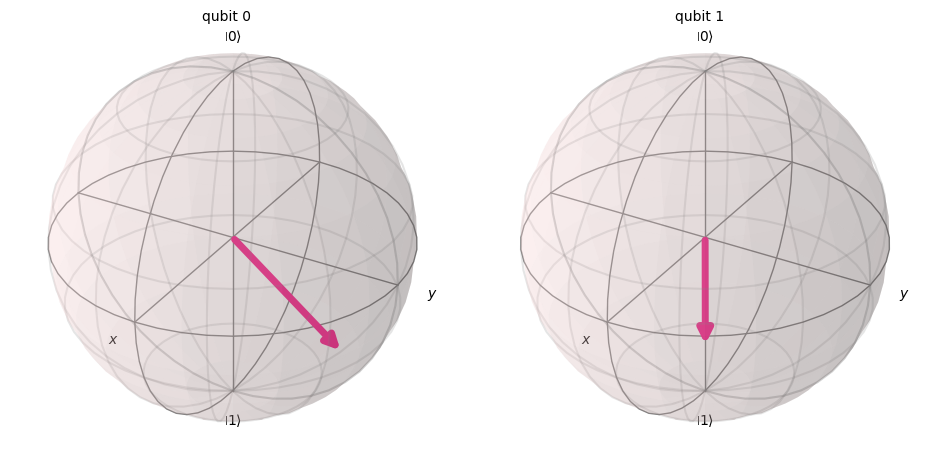

Circuit before transpilation


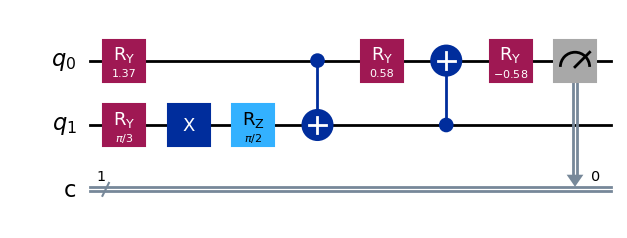

Circuit after transpilation


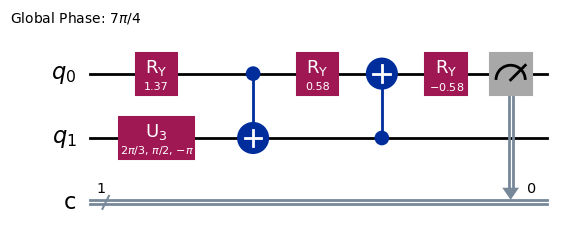

Counts:
{'0': 1452, '1': 2644}


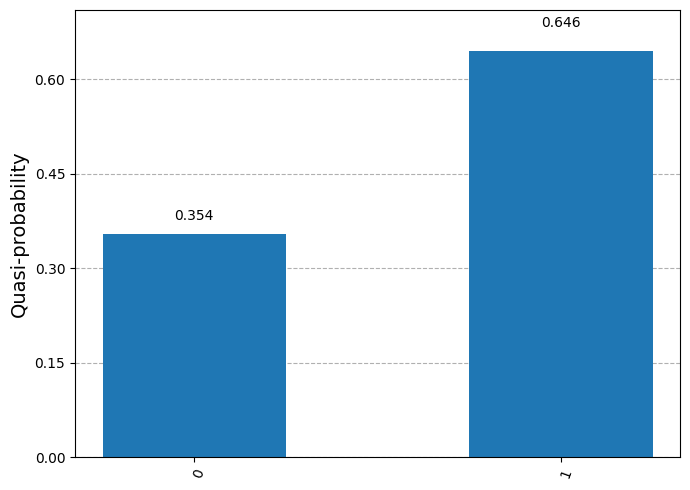

Actual EV of qubit 0: -0.2910
Theoretical EV (weighted sum): -0.2900
EV from statevector: -0.2900
Real value (x0 - x1): -0.3000


In [840]:
qc1 = QuantumCircuit(2, 1)

x0 = 0.2
x1 = 0.5
do_negation = 1

qc1.ry(np.arccos(x0), 0)
qc1.ry(np.arccos(x1), 1)

w = find_optimal_W(qc1, x0, x1, negation=do_negation, simulate=False)

qc1 = ehands_addition(qc1, 0, 1, w, negation=do_negation)

# Display the circuit and statevector
state = display_statevector(qc1)

qc_meas = qc1.copy()
qc_meas.measure(0, 0)

# Run simulation
n_shots = 2**12
counts = run_sim_job(qc_meas, n_shots=n_shots, verbose=True)

# Compute actual EV from measurement
ev_actual = (counts.get('0', 0) - counts.get('1', 0)) / n_shots

# Compute theoretical EV using weighted sum
if do_negation:
    ev_theory = w*x0 - (1-w)*x1
else:
    ev_theory = w*x0 + (1-w)*x1

print(f"Actual EV of qubit 0: {ev_actual:.4f}")
print(f"Theoretical EV (weighted sum): {ev_theory:.4f}")
print(f"EV from statevector: {state.expectation_value(Pauli('Z'), [0]):.4f}")
print(f"Real value (x0 {'-' if do_negation else '+'} x1): {x0 - x1 if do_negation else x0 + x1:.4f}")


## Marching Cubes Setup with QCrank

Number of address qubits needed: 3
Number of data qubits needed: 1
Input data values:
[[[0.        ]]

 [[0.14285714]]

 [[0.28571429]]

 [[0.42857143]]

 [[0.57142857]]

 [[0.71428571]]

 [[0.85714286]]

 [[1.        ]]]
Generated 1 data encoding circuits.
{'data_circs': [<qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000001B2C7F289F0>], 'param_qcrankObj': <datacircuits.ParametricQCrankV2.ParametricQCrankV2 object at 0x000001B2CA00BA40>, 'nq_addr': 3, 'nq_data': 1, 'addr_qubits': [0, 1, 2]}

Statevector:


<IPython.core.display.Latex object>


Statevector as a matrix:


<IPython.core.display.Latex object>

Unitary matrix:


<IPython.core.display.Latex object>

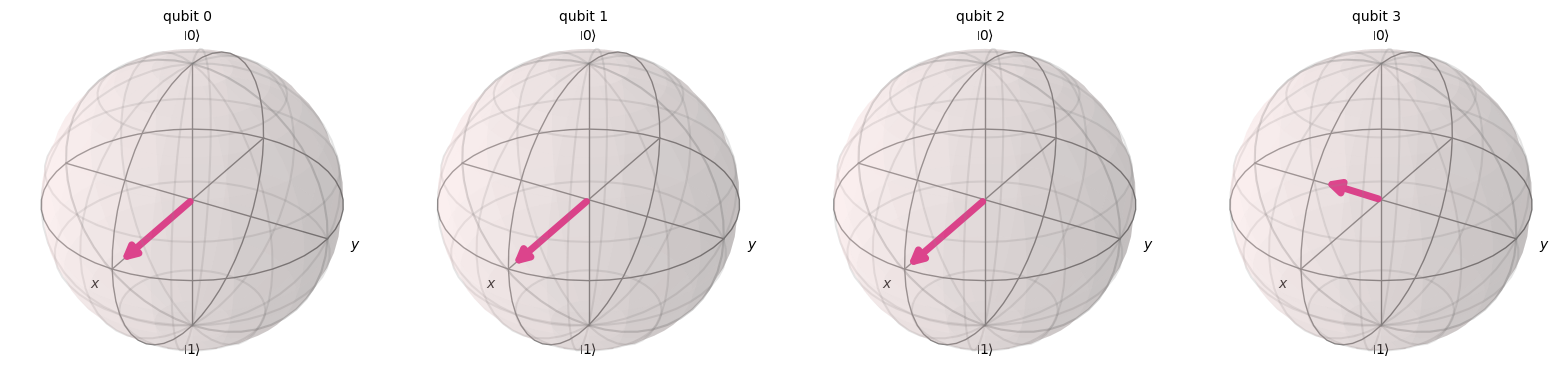

In [827]:
# Marching Cubes Vertex Classification
iso_value = 0.5

# Small sample data for testing
n_cubes = 1
n_data = n_cubes * 2**3
data = np.linspace(0, 1, n_data)

encoding_args = encode_with_qcrank(data)

print(encoding_args)

qc = encoding_args['data_circs'][0]
state = display_statevector(qc)


In [828]:
qc.measure_all()

counts = run_sim_job(qc, n_shots=2**10)

Element | <Z> Expectation | Original Value
   0    |     -0.3168     |     0.0000    
   1    |     -0.2571     |     0.1429    
   2    |     -0.1832     |     0.2857    
   3    |     -0.2000     |     0.4286    
   4    |     0.2115      |     0.5714    
   5    |     0.7600      |     0.7143    
   6    |     0.6203      |     0.8571    
   7    |     1.0000      |     1.0000    


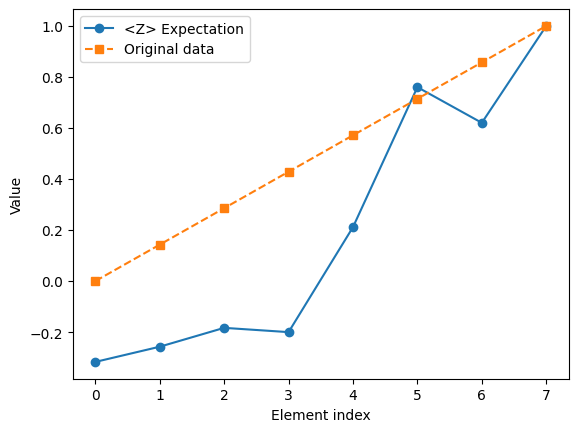

In [829]:
expectations = get_EV(counts, nq_addr, target_qubit='1')
print("Element | <Z> Expectation | Original Value")
for i, z in enumerate(expectations):
    print(f"{i:^7} | {z:^15.4f} | {data[i]:^14.4f}")

    
plt.plot(range(len(data)), expectations, 'o-', label='<Z> Expectation')
plt.plot(range(len(data)), data, 's--', label='Original data')
plt.xlabel('Element index')
plt.ylabel('Value')
plt.legend()
plt.show()